# PASTIS-R Filter for FarSLIP Preparation

Discards patches dominated by Background / Meadow so that FarSLIP
feature extraction focuses on informative crop patches.

**Filter rule**: keep a patch only if the combined pixel coverage of
a configurable set of *target classes* is ≥ `MIN_COVERAGE` of all
valid (non-void) pixels.

## Key parameters
| Parameter | Default | Meaning |
|-----------|---------|--------|
| `TARGET_CLASSES` | all crops except Meadow | class indices that count toward coverage |
| `MIN_COVERAGE` | 0.25 | minimum fraction of valid pixels in target classes |
| `IGNORE_INDEX` | 255 | void pixel value (excluded from denominator) |

## 0. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path
from getpass import getpass

_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

# En Colab el repo no esta presente: se clona una vez en /content/agrosat-copilot.
if _IN_COLAB:
    _repo_dir = '/content/agrosat-copilot'
    _branch = 'user/iavila/pastis-preparation-for-farslip'
    _repo = 'github.com/ArthurZizumbo/agrosat-copilot.git'
    if not Path(_repo_dir, 'pyproject.toml').is_file():
        _rc = os.system(f'git clone --branch {_branch} --depth 1 https://{_repo} {_repo_dir}')
        if _rc != 0:  # repo privado: pide token (no se guarda en el notebook)
            _tok = getpass('GitHub token (repo privado): ')
            os.system(f'git clone --branch {_branch} --depth 1 https://{_tok}@{_repo} {_repo_dir}')

# Localizar el repo por su pyproject.toml
_search = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
if _IN_COLAB:
    _search = [Path('/content/agrosat-copilot'), *_search]
for _cand in _search:
    if (_cand / 'pyproject.toml').is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        os.chdir(_cand)
        break
else:
    raise RuntimeError('No se encontro el repo agrosat-copilot (pyproject.toml). '
                       'Clonalo en /content/agrosat-copilot o sincronizalo desde VS Code.')

if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                    'structlog', 'polars'], check=False)

print('repo:', Path.cwd(), '| colab:', _IN_COLAB, '| drive:', shared_folder_path or '(local)')


Mounted at /content/drive
repo: /content/agrosat-copilot | colab: True | drive: /content/drive/MyDrive/Integrador/


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# guard: en caso de ejecutar esta celda de forma aislada
if 'shared_folder_path' not in dir():
    shared_folder_path = ''

# El dataset vive en Drive; en local se usa la copia del repo.
PASTIS_ROOT = Path((shared_folder_path + 'data/PASTIS-R') if shared_folder_path
                   else 'data/PASTIS-R')

# Artefactos de salida en Drive (misma estructura que el resto del equipo):
#   reports/farslip/data    -> parquet / json de splits filtrados
#   reports/farslip/figures -> PNG de distribuciones de cobertura
FARSLIP_DIR = Path((shared_folder_path if shared_folder_path else '') + 'reports/farslip')
DATA_DIR    = FARSLIP_DIR / 'data'
FIGURES_DIR = FARSLIP_DIR / 'figures'
for _d in (DATA_DIR, FIGURES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

print('PASTIS_ROOT :', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())
print('FARSLIP_DIR :', FARSLIP_DIR)


PASTIS_ROOT : /content/drive/MyDrive/Integrador/data/PASTIS-R | exists: True
FARSLIP_DIR : /content/drive/MyDrive/Integrador/reports/farslip


## 1. Configure filter parameters

In [3]:
from ml.data.pastis_filter import (
    PastisFilter, FilteredPASTISDataset,
    PASTIS_CLASS_NAMES, ALL_CROP_CLASSES, HCAT_GROUPS, CLASSES_OF_INTEREST
)

# ── Key parameters (reconfigurable) ──────────────────────────────────────────

# Minimum fraction of valid pixels that must belong to TARGET_CLASSES
MIN_COVERAGE = 0.25

# Ignore index (void pixels excluded from denominator)
IGNORE_INDEX = 255

# TARGET_CLASSES: which classes count toward the coverage threshold.
# Default: all crop classes EXCEPT Background (0), Meadow (1), Void (19)
# → only keep patches where ≥50% of valid pixels are actual crops.
#
# You can narrow this further, e.g. only cereals + oilseeds:
#   TARGET_CLASSES = HCAT_GROUPS['CEREALS'] + HCAT_GROUPS['OILSEEDS']
#
# Or only the 6 HCAT groups of interest:
#   TARGET_CLASSES = [c for g in HCAT_GROUPS.values() for c in g if c != 1]
TARGET_CLASSES = CLASSES_OF_INTEREST

print(f'MIN_COVERAGE   : {MIN_COVERAGE:.0%}')
print(f'IGNORE_INDEX   : {IGNORE_INDEX}')
print(f'TARGET_CLASSES : {sorted(TARGET_CLASSES)}')
print('Named classes  :')
for ci in sorted(TARGET_CLASSES):
    print(f'  [{ci:2d}] {PASTIS_CLASS_NAMES.get(ci, "?")}' )

MIN_COVERAGE   : 25%
IGNORE_INDEX   : 255
TARGET_CLASSES : [2, 3, 8]
Named classes  :
  [ 2] Soft winter wheat
  [ 3] Corn
  [ 8] Grapevine


## 2. EDA — coverage distribution before choosing threshold

Scan all patches and plot coverage distribution to validate
that `MIN_COVERAGE` is a sensible cutoff for your target classes.

Computing coverage stats (all folds) …

Patches scanned : 2433
Mean coverage   : 0.183
Median coverage : 0.155
P25 / P75       : 0.031 / 0.292
% above 30%     : 23.7%
% above 50%     : 4.8%
% above 70%     : 0.2%


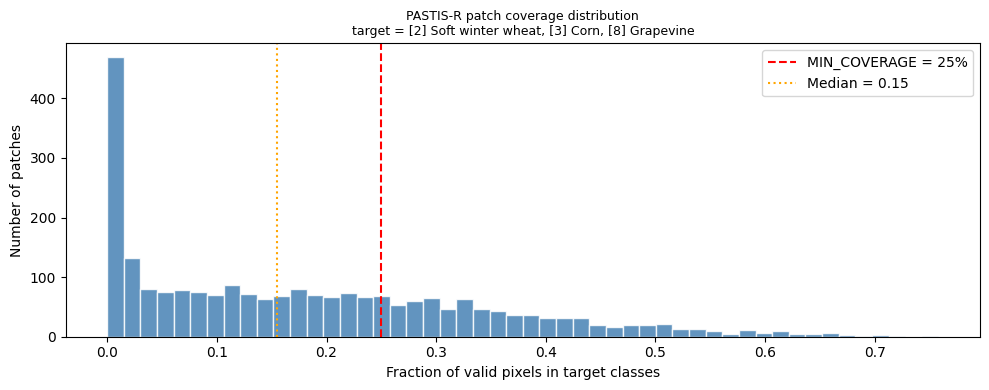

Patches kept with current threshold (25%): 780


In [4]:
filt = PastisFilter(
    pastis_root    = PASTIS_ROOT,
    target_classes = TARGET_CLASSES,
    min_coverage   = MIN_COVERAGE,
    ignore_index   = IGNORE_INDEX,
)

print('Computing coverage stats (all folds) …')
stats = filt.coverage_stats(folds=[1, 2, 3, 4, 5])

print(f"\nPatches scanned : {stats['n_patches']}")
print(f"Mean coverage   : {stats['mean']:.3f}")
print(f"Median coverage : {stats['median']:.3f}")
print(f"P25 / P75       : {stats['p25']:.3f} / {stats['p75']:.3f}")
print(f"% above 30%     : {stats['pct_above_30']:.1%}")
print(f"% above 50%     : {stats['pct_above_50']:.1%}")
print(f"% above 70%     : {stats['pct_above_70']:.1%}")

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stats['coverages'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(MIN_COVERAGE, color='red', linestyle='--', linewidth=1.5,
           label=f'MIN_COVERAGE = {MIN_COVERAGE:.0%}')
ax.axvline(stats['median'], color='orange', linestyle=':', linewidth=1.5,
           label=f'Median = {stats["median"]:.2f}')
ax.set_xlabel('Fraction of valid pixels in target classes')
ax.set_ylabel('Number of patches')
_class_labels = [f'[{c}] {PASTIS_CLASS_NAMES[c]}' for c in sorted(CLASSES_OF_INTEREST)]
_title_classes = ', '.join(_class_labels)
ax.set_title(
    f'PASTIS-R patch coverage distribution\n'
    f'target = {_title_classes}',
    fontsize=9
)
ax.legend()
plt.tight_layout()
plt.savefig('coverage_distribution.png', dpi=150)
plt.show()

kept = sum(1 for c in stats['coverages'] if c >= MIN_COVERAGE)
print(f'Patches kept with current threshold ({MIN_COVERAGE:.0%}): {kept}')

## 3. Apply filter and build DataLoaders

In [5]:
from torch.utils.data import DataLoader

train_ds = FilteredPASTISDataset(
    root=PASTIS_ROOT, folds=[1, 2, 3],
    target_classes=TARGET_CLASSES, min_coverage=MIN_COVERAGE,
    ignore_index=IGNORE_INDEX, collapse_time=None,
    n_timesteps=10, target='semantic18',
)
val_ds = FilteredPASTISDataset(
    root=PASTIS_ROOT, folds=[4],
    target_classes=TARGET_CLASSES, min_coverage=MIN_COVERAGE,
    ignore_index=IGNORE_INDEX, collapse_time=None,
    n_timesteps=10, target='semantic18',
)
test_ds = FilteredPASTISDataset(
    root=PASTIS_ROOT, folds=[5],
    target_classes=TARGET_CLASSES, min_coverage=MIN_COVERAGE,
    ignore_index=IGNORE_INDEX, collapse_time=None,
    n_timesteps=10, target='semantic18',
)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                          num_workers=1, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                          num_workers=1, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False,
                          num_workers=1, persistent_workers=True)

print(f'Train: {len(train_ds):4d} patches  ({train_ds.n_kept}/{train_ds.n_total})')
print(f'Val  : {len(val_ds):4d} patches  ({val_ds.n_kept}/{val_ds.n_total})')
print(f'Test : {len(test_ds):4d} patches  ({test_ds.n_kept}/{test_ds.n_total})')

2026-06-07 05:35:13 [info     ] pastis_seg_dataset_init        collapse_time=None folds=(1, 2, 3) has_norm_stats=True n_patches=1455 num_classes=18 target=semantic18
FilteredPASTISDataset: folds=[1, 2, 3] | target_classes=[2, 3, 8] | min_coverage=25% | kept=481/1455 (33.1%)
2026-06-07 05:35:15 [info     ] pastis_seg_dataset_init        collapse_time=None folds=(4,) has_norm_stats=True n_patches=482 num_classes=18 target=semantic18
FilteredPASTISDataset: folds=[4] | target_classes=[2, 3, 8] | min_coverage=25% | kept=154/482 (32.0%)
2026-06-07 05:35:17 [info     ] pastis_seg_dataset_init        collapse_time=None folds=(5,) has_norm_stats=True n_patches=496 num_classes=18 target=semantic18
FilteredPASTISDataset: folds=[5] | target_classes=[2, 3, 8] | min_coverage=25% | kept=145/496 (29.2%)
Train:  481 patches  (481/1455)
Val  :  154 patches  (154/482)
Test :  145 patches  (145/496)


## 4. Reconfiguration examples

Swap `TARGET_CLASSES` to target specific HCAT groups or individual crops.

In [6]:
# ── Example 1: only cereals + oilseeds (FarSLIP for grain/oil crops) ─────────
cereals_oilseeds = HCAT_GROUPS['CEREALS'] + HCAT_GROUPS['OILSEEDS']
filt_co = PastisFilter(PASTIS_ROOT, target_classes=cereals_oilseeds,
                       min_coverage=0.50, ignore_index=IGNORE_INDEX)
kept_co = filt_co.filter_folds([1, 2, 3, 4, 5])
print(f'Cereals+Oilseeds only: {len(kept_co)} patches kept')

# ── Example 2: minority classes only (FarSLIP for rare crops) ────────────────
minority = HCAT_GROUPS['LEGUMES'] + HCAT_GROUPS['ROOT_CROPS']
filt_min = PastisFilter(PASTIS_ROOT, target_classes=minority,
                        min_coverage=0.30,   # lower threshold — minority classes are rare
                        ignore_index=IGNORE_INDEX)
kept_min = filt_min.filter_folds([1, 2, 3, 4, 5])
print(f'Legumes+Root crops  : {len(kept_min)} patches kept')

# ── Example 3: permanent woody crops (vineyards, orchards) ───────────────────
woody = HCAT_GROUPS['PERMANENT_WOODY']
filt_w = PastisFilter(PASTIS_ROOT, target_classes=woody,
                      min_coverage=0.20,   # woody crops rarely dominate a full 128px patch
                      ignore_index=IGNORE_INDEX)
kept_w = filt_w.filter_folds([1, 2, 3, 4, 5])
print(f'Permanent woody     : {len(kept_w)} patches kept')

# ── Summary table ─────────────────────────────────────────────────────────────
import polars as pl
summary = pl.DataFrame({
    'configuration':   ['All crops (default)', 'Cereals+Oilseeds', 'Legumes+Root crops', 'Woody crops'],
    'target_classes':  [str(sorted(ALL_CROP_CLASSES)), str(sorted(cereals_oilseeds)),
                        str(sorted(minority)), str(sorted(woody))],
    'min_coverage':    [0.50, 0.50, 0.30, 0.20],
    'patches_kept':    [filt.total_scanned, len(kept_co), len(kept_min), len(kept_w)],
})
display(summary)

Cereals+Oilseeds only: 281 patches kept
Legumes+Root crops  : 1 patches kept
Permanent woody     : 181 patches kept


configuration,target_classes,min_coverage,patches_kept
str,str,f64,i64
"""All crops (default)""","""[2, 3, 4, 5, 6, 7, 8, 9, 10, 1…",0.5,0
"""Cereals+Oilseeds""","""[2, 3, 4, 5, 6, 7, 10, 11, 17,…",0.5,281
"""Legumes+Root crops""","""[9, 13, 14, 15]""",0.3,1
"""Woody crops""","""[8, 16]""",0.2,181


## 5. Exportar splits filtrados para FarSLIP

Guarda los IDs de patches válidos en `reports/farslip/data/` en Drive
(mismo patrón de artefactos que el resto del equipo).
No se requiere git push ni DVC desde el notebook —
los datos quedan disponibles en Drive para el pipeline FarSLIP.

In [7]:
import json
import polars as pl

# Get kept IDs per fold for FarSLIP
filt_full = PastisFilter(
    pastis_root    = PASTIS_ROOT,
    target_classes = TARGET_CLASSES,
    min_coverage   = MIN_COVERAGE,
    ignore_index   = IGNORE_INDEX,
)

farslip_splits = {}
for folds, split in [([1, 2, 3], 'train'), ([4], 'val'), ([5], 'test')]:
    kept = filt_full.filter_folds(folds)
    farslip_splits[split] = kept
    print(f'{split:5s}: {len(kept)} patches')

# ── JSON ──────────────────────────────────────────────────────────────────────
json_path = DATA_DIR / 'pastis_farslip_filtered_splits.json'
with open(json_path, 'w') as f:
    json.dump({
        'metadata': {
            'target_classes':      sorted(TARGET_CLASSES),
            'target_class_names':  {str(c): PASTIS_CLASS_NAMES[c] for c in sorted(TARGET_CLASSES)},
            'min_coverage':        MIN_COVERAGE,
            'ignore_index':        IGNORE_INDEX,
        },
        'splits': farslip_splits,
    }, f, indent=2)
print(f'JSON  guardado: {json_path}')

# ── Parquet ───────────────────────────────────────────────────────────────────
rows = [
    {'split': split, 'patch_id': pid}
    for split, ids in farslip_splits.items()
    for pid in ids
]
df = pl.DataFrame(rows)
parquet_path = DATA_DIR / 'pastis_farslip_filtered_splits.parquet'
df.write_parquet(parquet_path)
print(f'Parquet guardado: {parquet_path}')
display(df.group_by('split').len().sort('split'))


train: 481 patches
val  : 154 patches
test : 145 patches
JSON  guardado: /content/drive/MyDrive/Integrador/reports/farslip/data/pastis_farslip_filtered_splits.json
Parquet guardado: /content/drive/MyDrive/Integrador/reports/farslip/data/pastis_farslip_filtered_splits.parquet


split,len
str,u32
"""test""",145
"""train""",481
"""val""",154


In [8]:
if _IN_COLAB:
    import subprocess, shutil
    from getpass import getpass

    # Instalar dvc-gs si no está disponible
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', 'dvc', 'dvc-gs'], check=False)

    # Autenticar con GCS
    from google.colab import auth
    auth.authenticate_user()
    print('Autenticado con GCS')

    # Configurar identidad de git 
    GIT_EMAIL = 'isaac.avila.gut@gmail.com'
    GIT_NAME  = 'Isaac Avila'
    GIT_TOKEN = getpass('GitHub token: ')
    subprocess.run(['git', 'config', 'user.email', GIT_EMAIL], cwd=str(Path.cwd()))
    subprocess.run(['git', 'config', 'user.name',  GIT_NAME],  cwd=str(Path.cwd()))

    # Configurar remote con token para poder hacer push
    _branch = 'user/iavila/pastis-preparation-for-farslip'
    _repo   = 'github.com/ArthurZizumbo/agrosat-copilot.git'
    subprocess.run(['git', 'remote', 'set-url', 'origin', f'https://{GIT_TOKEN}@{_repo}'],
                   cwd=str(Path.cwd()))

    # Copiar el parquet al repo local (DVC solo puede trackear archivos dentro del repo)
    repo_data_dir = Path.cwd() / 'data'
    repo_data_dir.mkdir(parents=True, exist_ok=True)
    repo_parquet = repo_data_dir / 'pastis_farslip_filtered_splits.parquet'
    shutil.copy2(parquet_path, repo_parquet)
    print(f'Copiado al repo: {repo_parquet}')

    # Registrar con DVC y subir al remote
    rel_parquet = str(repo_parquet.relative_to(Path.cwd()))
    for cmd in [
        ['dvc', 'add', rel_parquet],
        ['dvc', 'push'],
        ['git', 'add', rel_parquet + '.dvc', '.gitignore', 'data/pastis_farslip_filtered_splits.json'],
        ['git', 'diff', '--cached', '--quiet']
    ]:
        cmd_str = ' '.join(cmd)
        print(f'$ {cmd_str}')
        r = subprocess.run(cmd, capture_output=True, text=True, cwd=str(Path.cwd()))
        if r.stdout: print(r.stdout.strip())
        if r.stderr: print(r.stderr.strip())
    
     # Commit only if there are staged changes
    r = subprocess.run(['git', 'diff', '--cached', '--quiet'],
                       cwd=str(Path.cwd()))
    if r.returncode != 0:   # returncode 1 = there ARE staged changes
        cmd = ['git', 'commit', '-m', 'data: add filtered PASTIS-R splits for FarSLIP (DVC)']
        r = subprocess.run(cmd, capture_output=True, text=True, cwd=str(Path.cwd()))
        print(r.stdout.strip())
        print(r.stderr.strip())
    else:
        print('Nothing new to commit')

    # Pull remote changes (rebase) then push
    for cmd in [
        ['git', 'pull', '--rebase', 'origin', _branch],
        ['git', 'push', 'origin', _branch],
    ]:
        cmd_str = ' '.join(cmd)
        print(f'$ {cmd_str}')
        r = subprocess.run(cmd, capture_output=True, text=True, cwd=str(Path.cwd()))
        if r.stdout: print(r.stdout.strip())
        if r.stderr: print(r.stderr.strip())
else:
    print('Skipping DVC push — not in Colab')

Autenticado con GCS
Copiado al repo: /content/agrosat-copilot/data/pastis_farslip_filtered_splits.parquet
$ dvc add data/pastis_farslip_filtered_splits.parquet
$ dvc push
Everything is up to date.
$ git add data/pastis_farslip_filtered_splits.parquet.dvc .gitignore data/pastis_farslip_filtered_splits.json
$ git diff --cached --quiet
Nothing new to commit
$ git pull --rebase origin user/iavila/pastis-preparation-for-farslip
Already up to date.
From https://github.com/ArthurZizumbo/agrosat-copilot
 * branch            user/iavila/pastis-preparation-for-farslip -> FETCH_HEAD
$ git push origin user/iavila/pastis-preparation-for-farslip
Everything up-to-date
